# Pertemuan 9 — Prediksi Diagnosis Kanker Payudara
## Logistic Regression vs Decision Tree

Nama: Alini Syawalia Riski Fenanda
NIM: 240401010213

## Langkah 1: Load Data & EDA Singkat

Dataset yang digunakan adalah Breast Cancer Wisconsin dari scikit-learn, terdiri dari 569 sampel dengan 30 fitur numerik hasil pengukuran citra sel (ukuran, tekstur, simetri, dan sebagainya). Target bersifat biner: 0 = Malignant (ganas), 1 = Benign (jinak). Pada langkah ini dataset dimuat, lalu dicek ukurannya dan proporsi masing-masing kelas target.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print('Shape:', X.shape)
print('\nDistribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)

Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


Hasil di atas menunjukkan dataset memiliki 569 baris dan 30 kolom fitur. Distribusi target sekitar 62.7% Benign dan 37.3% Malignant, artinya dataset cukup seimbang (tidak terlalu *imbalance*) sehingga accuracy masih cukup informatif untuk dilihat, meskipun tetap perlu dilengkapi metrik lain seperti Recall.

Selanjutnya dicek korelasi antar beberapa fitur utama untuk melihat apakah ada fitur yang saling berhubungan kuat (multicollinearity), yang bisa memengaruhi interpretasi koefisien pada Logistic Regression nanti.

In [2]:
fitur_utama = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
X[fitur_utama].corr().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
mean radius,1.00,0.32,1.00,0.99,0.17
mean texture,0.32,1.00,0.33,0.32,-0.02
mean perimeter,1.00,0.33,1.00,0.99,0.21
mean area,0.99,0.32,0.99,1.00,0.18
mean smoothness,0.17,-0.02,0.21,0.18,1.00


Terlihat bahwa `mean radius`, `mean perimeter`, dan `mean area` berkorelasi sangat tinggi satu sama lain (mendekati 1.0). Hal ini wajar karena ketiganya sama-sama mengukur "ukuran" sel dari sudut pandang berbeda (jari-jari, keliling, luas).

## Langkah 2: Preprocessing

Data dibagi menjadi data latih (80%) dan data uji (20%) menggunakan `stratify=y` agar proporsi kelas Malignant/Benign tetap seimbang di kedua bagian. Selanjutnya `StandardScaler` diterapkan pada fitur karena Logistic Regression sensitif terhadap skala data (menggunakan perhitungan jarak/gradien), sedangkan Decision Tree tidak memerlukan scaling karena hanya melakukan pembagian (split) berdasarkan threshold nilai fitur.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Jumlah data latih:', X_train.shape[0])
print('Jumlah data uji  :', X_test.shape[0])

Jumlah data latih: 455
Jumlah data uji  : 114


## Langkah 3: Melatih Logistic Regression

Model Logistic Regression dilatih menggunakan data yang sudah distandarisasi (`X_train_s`). Setelah itu, koefisien tiap fitur ditampilkan untuk melihat fitur mana yang paling berpengaruh terhadap prediksi.

In [4]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print(coef_df.head(8))

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616
28        worst symmetry  -0.939181
13            area error  -0.929104
26       worst concavity  -0.823151


Karena target dikodekan 1 = Benign, koefisien negatif berarti semakin besar nilai fitur tersebut, semakin besar kemungkinan tumor bersifat Malignant. Dari hasil di atas, fitur-fitur seperti `worst texture`, `radius error`, dan `worst concave points` adalah yang paling berpengaruh — semuanya berkaitan dengan ukuran sel yang besar/tidak beraturan dan tekstur kasar, ciri umum sel kanker ganas secara medis.

## Langkah 4: Melatih Decision Tree

Decision Tree dilatih pada data asli (`X_train`, tanpa scaling) dengan kedalaman maksimum 4 (`max_depth=4`) agar pohon tidak terlalu kompleks dan menghindari overfitting. Pohon yang terbentuk kemudian divisualisasikan agar mudah dipahami alur pengambilan keputusannya.

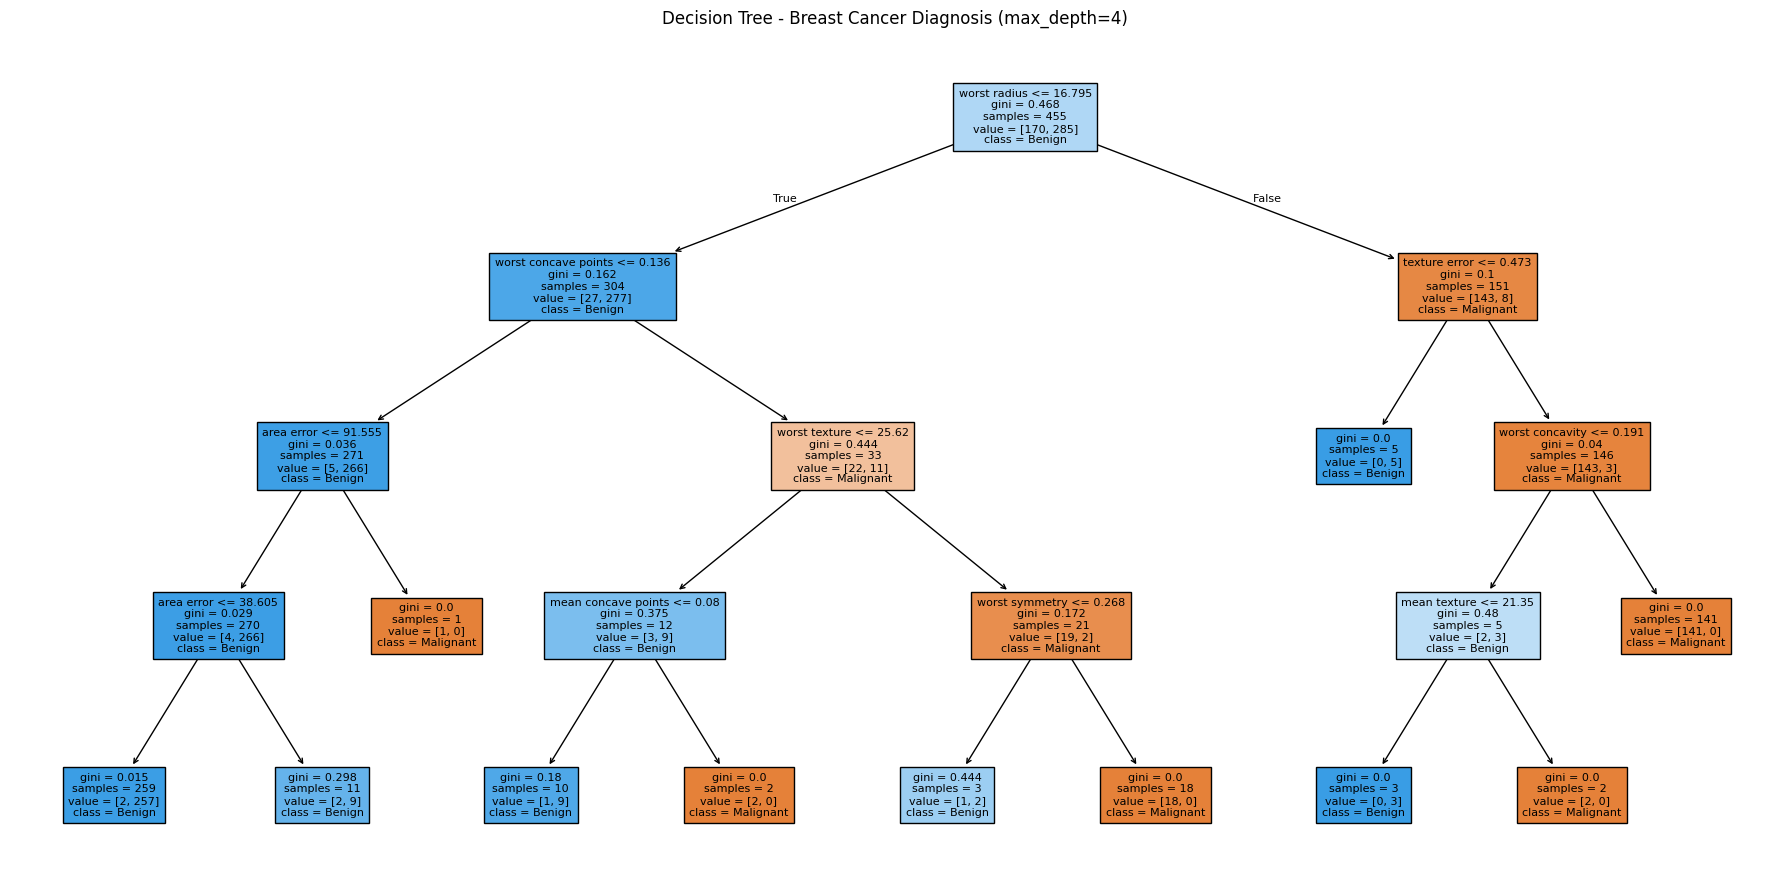

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18, 9))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True, fontsize=8)
plt.title("Decision Tree - Breast Cancer Diagnosis (max_depth=4)")
plt.tight_layout()
plt.show()

Selain visualisasi pohon, bisa juga dilihat seberapa besar kontribusi tiap fitur terhadap keputusan split pada Decision Tree melalui `feature_importances_`.

In [6]:
imp_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(imp_df.head(8))

                   Fitur  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161
7    mean concave points    0.013327
13            area error    0.012704
1           mean texture    0.011846


Biasanya `worst radius` akan tampil sebagai fitur paling dominan (kontribusi bisa di atas 70%), karena fitur ini dipakai sebagai split pertama (root node) yang langsung memisahkan sebagian besar data dengan baik. Berbeda dengan Logistic Regression yang menyebar bobot pengaruh ke banyak fitur sekaligus, Decision Tree cenderung sangat bergantung pada satu-dua fitur utama di level atas pohonnya.

## Langkah 5: Evaluasi & Perbandingan Model

Pada langkah ini dihitung Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score untuk kedua model agar bisa dibandingkan performanya secara menyeluruh, terutama dari sisi Recall yang penting untuk kasus medis (menghindari False Negative, yaitu kasus kanker yang terlewat).

In [7]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


Agar lebih mudah dibandingkan, hasil keempat metrik dari kedua model dirangkum dalam satu tabel.

In [8]:
hasil = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_tree)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_tree)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_tree)],
    'F1-Score': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_tree)],
}).round(3)
hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982,0.986,0.986,0.986
1,Decision Tree,0.939,0.958,0.944,0.951


## Pembahasan

**Model mana yang Recall-nya lebih tinggi?**
[Sebutkan angka Recall masing-masing model dari hasil sel 19, lalu lihat juga confusion matrix-nya — berapa False Negative tiap model.]

**Mengapa Recall lebih kritis daripada Accuracy untuk diagnosis kanker?**
[Jelaskan: False Negative (kanker ganas diprediksi jinak) jauh lebih berbahaya daripada False Positive, karena pasien jadi tidak mendapat penanganan padahal sebenarnya sakit. Accuracy bisa menyesatkan kalau data tidak seimbang, karena model yang selalu menebak kelas mayoritas pun bisa dapat accuracy tinggi tanpa benar-benar mendeteksi kanker.]

**Apakah ada perbedaan signifikan antara kedua model?**
[Bandingkan semua metrik di tabel sel 21, sebutkan selisihnya, dan beri alasan kenapa bisa berbeda — misalnya soal data yang cenderung linear-separable, batasan max_depth, atau sensitivitas Decision Tree terhadap noise.]